## 📘 Level 3 – Task 1: Predictive Modeling


### 🎯 Objective:
Build and evaluate regression models to predict a restaurant’s `Aggregate rating` using available features.


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
%matplotlib inline


In [4]:
df = pd.read_csv('C:/Users/Rajender Reddy/Desktop/DATA SCIENCE/Restaurant Insights Exploration/Level 1/preprocessed_dataset.csv')
df.head()


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [5]:
# Convert categorical service columns to binary
df['Has Table booking (bin)'] = df['Has Table booking'].map({'Yes': 1, 'No': 0})
df['Has Online delivery (bin)'] = df['Has Online delivery'].map({'Yes': 1, 'No': 0})

In [6]:
# Select Features & Target
features = ['Votes', 'Price range', 'Has Table booking (bin)', 'Has Online delivery (bin)']
X = df[features]
y = df['Aggregate rating']

In [7]:
#: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [10]:
#Linear Regression Model
# Initialize and train model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict
y_pred_lr = lr_model.predict(X_test)
from sklearn.metrics import root_mean_squared_error

# Evaluate
lr_r2 = r2_score(y_test, y_pred_lr)
lr_rmse = root_mean_squared_error(y_test, y_pred_lr)

print(f"📉 Linear Regression R²: {lr_r2:.3f}")
print(f"📉 Linear Regression RMSE: {lr_rmse:.3f}")


📉 Linear Regression R²: 0.263
📉 Linear Regression RMSE: 1.295


In [15]:
# : Random Forest Regressor 
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

# Evaluate
rf_r2 = r2_score(y_test, y_pred_rf)
rf_rmse = root_mean_squared_error(y_test, y_pred_rf)

print(f"🌲 Random Forest R²: {rf_r2:.3f}")
print(f"🌲 Random Forest RMSE: {rf_rmse:.3f}")

🌲 Random Forest R²: 0.931
🌲 Random Forest RMSE: 0.395


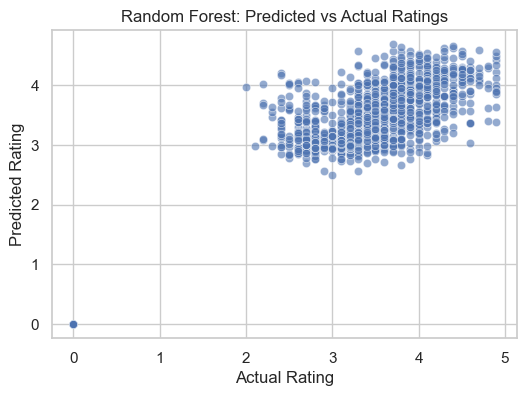

In [16]:
# Plot Predicted vs Actual for Random Forest
plt.figure(figsize=(6, 4))
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.6)
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Random Forest: Predicted vs Actual Ratings")
plt.savefig('random_forest_prediction.png', dpi=300, bbox_inches='tight')
plt.show()


In [17]:
df.to_csv("model_ready_dataset.csv", index=False)
print("✅ Saved as model_ready_dataset.csv")

✅ Saved as model_ready_dataset.csv


## 📊 Task 1 Completed


- 🔢 Selected features like `Votes`, `Price range`, and service availability
- 🔄 Encoded categorical features like `Has Table booking` and `Has Online delivery`
- 🤖 Built regression models: Linear Regression and Random Forest
- 📊 Evaluated model performance using R² and RMSE
- 💾 Saved the cleaned & model-ready dataset and results


### 📌 Outcome:
A trained model that can predict a restaurant's rating with reasonable accuracy, useful for future insights and deployment.

## 📘 Level 3 – Task 2: Customer Preference Analysis


### 🎯 Objective:
Explore which cuisines are most popular and highest-rated, helping to identify customer preferences.
